# Theta en Hull–White: estimación por diferencias finitas

**Objetivo del notebook.** Estimar la Theta de una opción europea bajo el modelo de Hull–White mediante diferencias finitas centradas con CRN. El método pathwise no es aplicable: el parámetro $T$ aparece simultáneamente como límite superior del descuento estocástico $D^{(n)} = \exp\!\bigl(-\sum_{k=0}^{M-1} r_{t_k}^{(n)}\,\Delta t\bigr)$ y como horizonte de la dinámica de $S_T$, sin que exista una regla de la cadena directa que relacione $\partial S_T / \partial T$ con la trayectoria simulada.

Siguiendo la convención del Cap. 3, $\Theta = -\partial V_0 / \partial T$. El estimador empleado es

$$
\widehat{\Theta}^{\,FD} \;=\; -\,\frac{\widehat{V}_0(T+h) - \widehat{V}_0(T-h)}{2h},
$$

con CRN entre las dos valoraciones (misma semilla).

**Nota sobre CRN en Theta.** Perturbar $T$ cambia el paso temporal $\Delta t = (T \pm h)/M$. Las dos simulaciones comparten los mismos números aleatorios pero se evalúan sobre rejillas temporales distintas. La curva de descuento $P(0,T)$ utilizada para calibrar $\theta(t)$ también se reevalúa en $T \pm h$; bajo la curva plana del notebook ($P(0,T) = e^{-r_{\text{flat}}T}$) este efecto está incorporado de forma exacta.

El notebook contiene:

1. Estimación puntual con los parámetros de referencia del Cap. 4.
2. Banda de incertidumbre del estimador FD mediante repeticiones independientes.
3. Sensibilidad respecto al paso de perturbación $h$.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from hullwhite import GeneratePathsHWAndAssetEuler, P0T, PriceEuropeanOptionHWMC

np.set_printoptions(suppress=True, precision=6)

## 1. Parámetros del experimento

Parámetros estándar del Cap. 4.

In [2]:
S0          = 100.0
K           = 100.0
sigma_S     = 0.20
lambd       = 0.5
eta         = 0.01
rho         = -0.3
T           = 1.0
N           = 20_000
M           = 250
SEED        = 3
option_type = "call"

## 2. Estimador FD

La restricción $T - h > 0$ es necesaria para que la valoración en $T - h$ esté bien definida.

In [3]:
def ThetaFD_HW_MC(NoOfPaths, NoOfSteps, T, P0T, lambd, eta,
                  S0, sigma_S, rho, K, h,
                  option_type="call", seed=SEED):
    """
    Theta por diferencias finitas centradas en Hull-White, con CRN.

    Devuelve theta_fd (anual) y los dos precios para inspeccion.
    """
    if T - h <= 0:
        raise ValueError(f"T - h debe ser positivo. Recibido T = {T}, h = {h}.")

    paths_up = GeneratePathsHWAndAssetEuler(
        NoOfPaths, NoOfSteps, T + h, P0T, lambd, eta,
        S0, sigma_S, rho, seed=seed)
    price_up, _ = PriceEuropeanOptionHWMC(paths_up, K, T + h, option_type)

    paths_dn = GeneratePathsHWAndAssetEuler(
        NoOfPaths, NoOfSteps, T - h, P0T, lambd, eta,
        S0, sigma_S, rho, seed=seed)
    price_dn, _ = PriceEuropeanOptionHWMC(paths_dn, K, T - h, option_type)

    theta_fd = -(price_up - price_dn) / (2.0 * h)
    return theta_fd, price_up, price_dn

## 3. Estimación puntual

Se calcula el estimador con $h = 1/365$ (perturbación de un día natural).

In [4]:
h = 1.0 / 365.0

theta_fd, p_up, p_dn = ThetaFD_HW_MC(
    N, M, T, P0T, lambd, eta, S0, sigma_S, rho, K,
    h=h, option_type=option_type, seed=SEED)

print(f"V(T + h) = {p_up:.6f}")
print(f"V(T - h) = {p_dn:.6f}")
print()
print(f"Theta FD (anual)  = {theta_fd:.6f}")
print(f"Theta FD (diaria) = {theta_fd / 365:.6f}")

V(T + h) = 10.290440
V(T - h) = 10.256037

Theta FD (anual)  = -6.278530
Theta FD (diaria) = -0.017201


El signo negativo confirma el decaimiento temporal habitual de la call europea. La banda de incertidumbre asociada a este estimador puntual se cuantifica en la siguiente sección mediante repeticiones independientes.

## 4. Banda de incertidumbre del estimador FD

La Theta es un estimador FD-only. Para cuantificar su precisión se repite la estimación sobre $n_{\text{rep}}$ simulaciones independientes (semillas distintas) manteniendo $N$ fijo y conservando CRN dentro de cada repetición. La desviación típica muestral sobre las repeticiones estima el error estándar de un estimador individual.

In [5]:
n_rep     = 60
base_seed = 1000

def ThetaRepeticiones_HW(n_rep, base_seed, h):
    """
    Repite la estimacion de Theta sobre n_rep simulaciones independientes
    a N fijo. Dentro de cada repeticion se emplea CRN (misma semilla
    en T+h y T-h); entre repeticiones la semilla cambia. La desviacion
    tipica muestral sobre las repeticiones estima el error estandar
    de un estimador individual.
    """
    theta = np.empty(n_rep)
    for j in range(n_rep):
        s = base_seed + j
        theta[j], _, _ = ThetaFD_HW_MC(
            N, M, T, P0T, lambd, eta, S0, sigma_S, rho, K,
            h=h, option_type=option_type, seed=s)
    return theta

theta_rep = ThetaRepeticiones_HW(n_rep, base_seed, h=h)

media_theta = theta_rep.mean()
se_theta    = theta_rep.std(ddof=1)

print(f"Repeticiones: {n_rep}   (N = {N}, M = {M}, h = 1/365)")
print(f"Media (anual):    {media_theta:.6f}")
print(f"SE (rep, anual):  {se_theta:.6f}")
print(f"IC 95% (asintotico): [{media_theta - 1.96*se_theta:.6f}, {media_theta + 1.96*se_theta:.6f}]")

Repeticiones: 60   (N = 20000, M = 250, h = 1/365)
Media (anual):    -6.358053
SE (rep, anual):  0.056685
IC 95% (asintotico): [-6.469157, -6.246950]


La SE empírica obtenida proporciona la banda de incertidumbre que acompañará al estimador puntual. En el barrido en $h$ que sigue, cualquier oscilación dentro de $\pm\,\text{SE}$ debe atribuirse al error Monte Carlo y no a un efecto sistemático del paso de perturbación.

## 5. Sensibilidad respecto a $h$

A diferencia de Gamma, el cociente de Theta divide por $2h$ (no por $h^2$), de modo que la amplificación del ruido para $h$ pequeño es mucho menor. Se espera un comportamiento estable en el rango de perturbaciones financieramente significativas (de un día a un trimestre).

In [8]:
h_grid   = np.array([0.25, 0.10, 0.05, 30.0/365.0, 7.0/365.0, 1.0/365.0])
h_labels = ["3M",  "0,10", "0,05", "1M (30d)",       "1W (7d)",      "1d"]
import pandas as pd
results = []
for h_val in h_grid:
    t, pu, pd_sd = ThetaFD_HW_MC(
        N, M, T, P0T, lambd, eta, S0, sigma_S, rho, K,
        h=h_val, option_type=option_type, seed=SEED)
    results.append({
        "h"        : h_val,
        "V(T+h)"   : pu,
        "V(T-h)"   : pd_sd,
        "Theta_FD" : t,
    })

df_h = pd.DataFrame(results)
df_h["etiqueta"] = h_labels
df_h

,h,V(T+h),V(T-h),Theta_FD,etiqueta
0,0.250000,11.784853,8.629841,-6.310023,3M
1,0.100000,10.891254,9.634542,-6.283557,"0,10"
2,0.050000,10.584662,9.956670,-6.279917,"0,05"
3,0.082192,10.782589,9.749936,-6.281972,1M (30d)
4,0.019178,10.393283,10.152453,-6.278774,1W (7d)
5,0.002740,10.290440,10.256037,-6.278530,1d


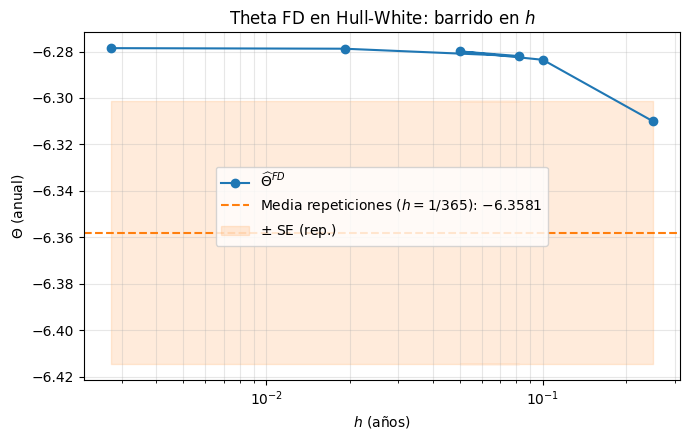

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.semilogx(df_h["h"], df_h["Theta_FD"], marker="o", label=r"$\widehat{\Theta}^{FD}$")
ax.axhline(media_theta, color="C1", linestyle="--",
           label=fr"Media repeticiones $(h=1/365)$: ${media_theta:.4f}$")
ax.fill_between(
    df_h["h"],
    media_theta - se_theta, media_theta + se_theta,
    color="C1", alpha=0.15, label=r"$\pm$ SE (rep.)"
)

ax.set_xlabel(r"$h$ (años)")
ax.set_ylabel(r"$\Theta$ (anual)")
ax.set_title("Theta FD en Hull-White: barrido en $h$")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

**Lectura del barrido.** La banda $\pm\,\text{SE}$ obtenida por repeticiones delimita el rango de variación atribuible al error Monte Carlo. Se contrastan tres regímenes:

- **Sesgo de truncamiento** ($h$ grande): si la estimación se separa sistemáticamente de la media de referencia con $h$ creciente, el término $\mathcal{O}(h^2)$ del cociente de diferencias finitas empieza a ser apreciable.
- **Régimen estable**: rango de $h$ en el que $\widehat{\Theta}^{FD}$ permanece dentro de la banda $\pm\,\text{SE}$, indicando que sesgo y varianza son ambos pequeños.
- **Ruido amplificado** ($h$ pequeño): a diferencia de Gamma, el divisor $2h$ produce una amplificación moderada del ruido y este régimen suele quedar acotado dentro de la banda en los rangos considerados.

## 6. Conclusiones

1. La Theta en Hull–White se estima mediante FD centrada sobre el vencimiento $T$, con CRN. El método pathwise no es aplicable.
2. La banda de incertidumbre del estimador se obtiene por $n_{\text{rep}} = 60$ repeticiones independientes y sustituye al contraste con pathwise que sí existía para Delta y Vega.
3. El barrido en $h$ muestra estabilidad apreciable en el rango financieramente relevante ($1/365 \le h \le 0{,}25$), consistente con el comportamiento esperado de un cociente de primer orden sobre una función $V_0(T)$ suave.